In [13]:
library(readr)
library(ggcorrplot)
df <- read_csv("mxmh_survey_results.csv")
head(df)
library(dplyr)
numeric_df <- df %>% select(where(is.numeric))

Rows: 736 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (26): Timestamp, Primary streaming service, While working, Instrumentali...
dbl  (7): Age, Hours per day, BPM, Anxiety, Depression, Insomnia, OCD

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,⋯,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
8/27/2022 19:29:02,18,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,⋯,Sometimes,Very frequently,Never,Sometimes,3,0,1,0,NA,I understand.
8/27/2022 19:57:31,63,Pandora,1.5,Yes,No,No,Rock,Yes,No,⋯,Sometimes,Rarely,Very frequently,Rarely,7,2,2,1,NA,I understand.
8/27/2022 21:28:18,18,Spotify,4.0,No,No,No,Video game music,No,Yes,⋯,Never,Rarely,Rarely,Very frequently,7,7,10,2,No effect,I understand.
8/27/2022 21:40:40,61,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,⋯,Sometimes,Never,Never,Never,9,7,3,3,Improve,I understand.
8/27/2022 21:54:47,18,Spotify,4.0,Yes,No,No,R&B,Yes,No,⋯,Very frequently,Very frequently,Never,Rarely,7,2,5,9,Improve,I understand.
8/27/2022 21:56:50,18,Spotify,5.0,Yes,Yes,Yes,Jazz,Yes,Yes,⋯,Very frequently,Very frequently,Very frequently,Never,8,8,7,7,Improve,I understand.


[1] "Корреляция Пирсона:"
                  Age Hours per day     BPM Anxiety Depression Insomnia     OCD
Age            1.0000       -0.0446 -0.0268 -0.1765    -0.1215   0.0069 -0.1299
Hours per day -0.0446        1.0000  0.0401  0.0493     0.1105   0.1418  0.1187
BPM           -0.0268        0.0401  1.0000 -0.0248     0.0379   0.0500  0.0176
Anxiety       -0.1765        0.0493 -0.0248  1.0000     0.5200   0.2927  0.3483
Depression    -0.1215        0.1105  0.0379  0.5200     1.0000   0.3790  0.1970
Insomnia       0.0069        0.1418  0.0500  0.2927     0.3790   1.0000  0.2264
OCD           -0.1299        0.1187  0.0176  0.3483     0.1970   0.2264  1.0000
[1] "Корреляция Спирмена:"
                  Age Hours per day     BPM Anxiety Depression Insomnia     OCD
Age            1.0000       -0.1406  0.0657 -0.0682     0.0083   0.0212 -0.0898
Hours per day -0.1406        1.0000 -0.0713  0.0943     0.1352   0.1481  0.1254
BPM            0.0657       -0.0713  1.0000  0.0071    -0.0038   0.

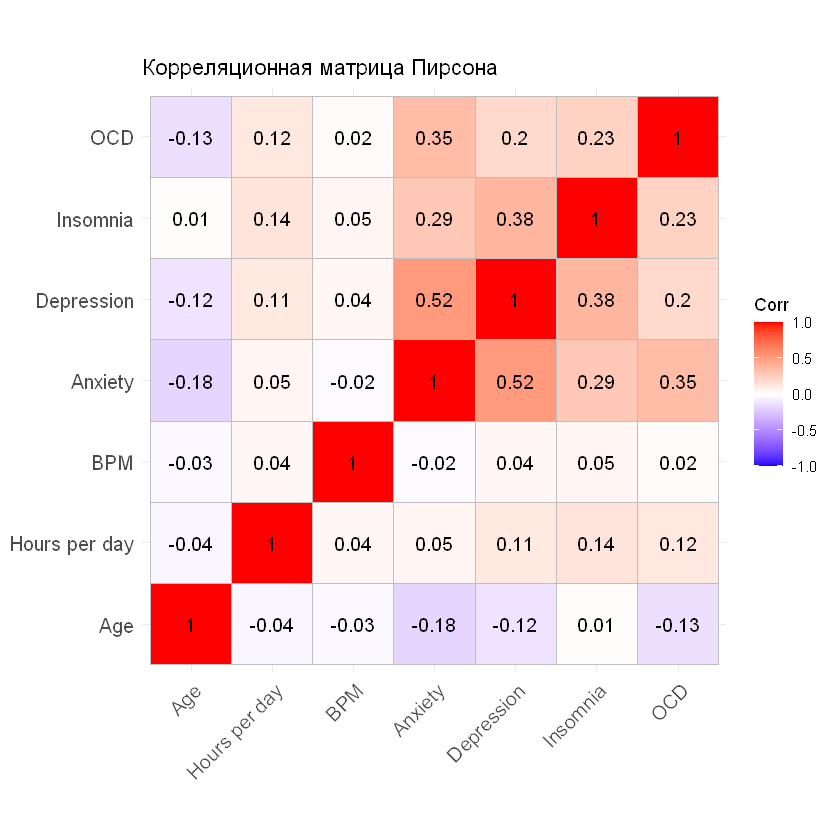

In [14]:
numeric_df <- numeric_df %>% 
  mutate(across(everything(), ~ ifelse(is.na(.), mean(., na.rm = TRUE), .)))

pearson_corr <- cor(numeric_df, method = "pearson")
spearman_corr <- cor(numeric_df, method = "spearman")

print("Корреляция Пирсона:")
print(round(pearson_corr, 4))
print("Корреляция Спирмена:")
print(round(spearman_corr, 4))

library(ggcorrplot)
ggcorrplot(pearson_corr, lab = TRUE, title = "Корреляционная матрица Пирсона")


Call:
lm(formula = Depression ~ Age, data = Y)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.7044 -1.3078  0.2407  1.1940  7.2096 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  5.61540    0.56029  10.022 1.96e-14 ***
Age         -0.04154    0.01191  -3.489 0.000916 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.872 on 60 degrees of freedom
Multiple R-squared:  0.1686,	Adjusted R-squared:  0.1548 
F-statistic: 12.17 on 1 and 60 DF,  p-value: 0.000916


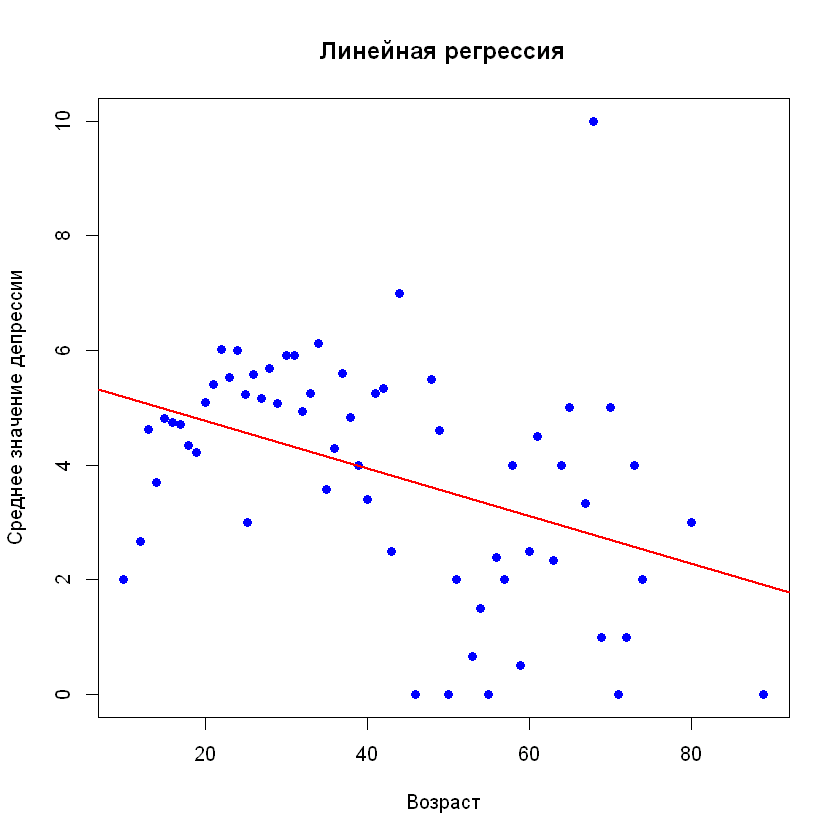

In [15]:
df$Depression[is.na(df$Depression)] <- mean(df$Depression, na.rm = TRUE)
df$Age[is.na(df$Age)] <- mean(df$Age, na.rm = TRUE)

Y <- aggregate(Depression ~ Age, data = df, FUN = mean)

# Создание модели линейной регрессии
model <- lm(Depression ~ Age, data = Y)
summary(model)  # Вывод сводной статистики

# Построение графика
plot(Y$Age, Y$Depression,
     main = "Линейная регрессия",
     xlab = "Возраст",
     ylab = "Среднее значение депрессии",
     col = "blue",
     pch = 19)

# Добавление линии регрессии
abline(model, col = "red", lwd = 2)